# MSCS 634 - Lab 1: Data Visualization, Preprocessing and Statistical Analysis

**Name:** Fortunato Hernandez
**Course:** MSCS 634
**Assignment:** Lab 1

---
## Step 1: Data Collection

We generate a synthetic retail sales dataset spanning two years (2023-2024) across multiple product categories, regions, and customer segments.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

n = 500
categories = ['Electronics', 'Clothing', 'Home & Garden', 'Sports', 'Books']
regions     = ['North', 'South', 'East', 'West']
segments    = ['Consumer', 'Corporate', 'Home Office']

dates = pd.date_range('2023-01-01', '2024-12-31', periods=n)

df = pd.DataFrame({
    'Order_Date':       dates,
    'Category':         np.random.choice(categories, n),
    'Region':           np.random.choice(regions, n),
    'Customer_Segment': np.random.choice(segments, n),
    'Quantity':         np.random.randint(1, 20, n),
    'Unit_Price':       np.round(np.random.uniform(5, 500, n), 2),
    'Discount':         np.round(np.random.uniform(0, 0.4, n), 2),
    'Shipping_Cost':    np.round(np.random.uniform(2, 50, n), 2),
    'Customer_Rating':  np.round(np.random.uniform(1, 5, n), 1),
})

df['Revenue'] = np.round(df['Quantity'] * df['Unit_Price'] * (1 - df['Discount']), 2)
df['Profit']  = np.round(df['Revenue'] - df['Shipping_Cost'] - (df['Quantity'] * df['Unit_Price'] * 0.6), 2)

# Inject ~5% missing values
for col in ['Discount', 'Customer_Rating', 'Shipping_Cost']:
    df.loc[df.sample(frac=0.05, random_state=42).index, col] = np.nan

# Inject outliers in Revenue
outlier_idx = np.random.choice(df.index, 8, replace=False)
df.loc[outlier_idx, 'Revenue'] = df['Revenue'].mean() + np.random.uniform(4, 6, 8) * df['Revenue'].std()

df.to_csv('retail_sales.csv', index=False)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (500, 11)


,Order_Date,Category,Region,Customer_Segment,Quantity,Unit_Price,Discount,Shipping_Cost,Customer_Rating,Revenue,Profit
0,2023-01-01 00:00:00.000000000,Sports,South,Corporate,11,168.79,0.26,33.00,2.4,1373.95,226.94
1,2023-01-02 11:06:36.793587174,Books,West,Home Office,17,227.14,0.12,4.15,4.3,3398.01,1077.03
2,2023-01-03 22:13:13.587174348,Home & Garden,West,Consumer,13,336.35,0.30,38.57,3.1,3060.78,398.68
3,2023-01-05 09:19:50.380761523,Books,North,Home Office,11,77.15,0.33,47.44,2.9,568.60,11.97
4,2023-01-06 20:26:27.174348697,Books,South,Corporate,2,227.47,0.25,18.31,1.2,341.20,49.93


---
## Step 2: Data Visualization

### 2.1 Scatter Plot - Revenue vs Quantity (colored by Category)

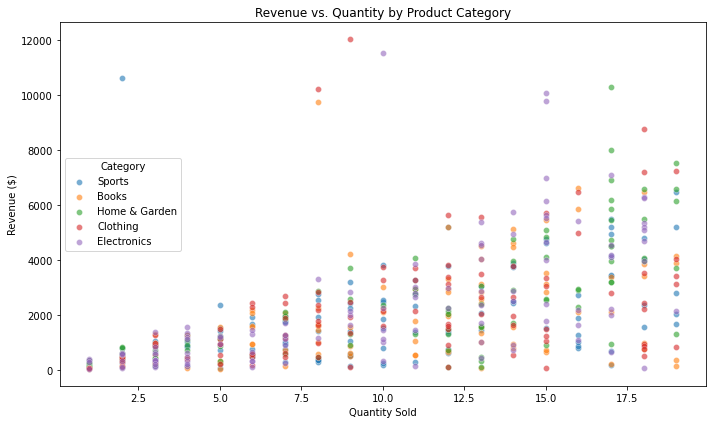

In [3]:
plt.figure(figsize=(10, 6))
for cat in df['Category'].unique():
    subset = df[df['Category'] == cat]
    plt.scatter(subset['Quantity'], subset['Revenue'], alpha=0.6, label=cat, edgecolors='w', linewidth=0.4)
plt.xlabel('Quantity Sold')
plt.ylabel('Revenue ($)')
plt.title('Revenue vs. Quantity by Product Category')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

**Insight:** Revenue increases with quantity, but the slope varies by category. Electronics transactions cluster at higher revenue for any given quantity (higher unit prices), while Books stay in the lower-revenue band.

### 2.2 Line Plot - Monthly Revenue Trend

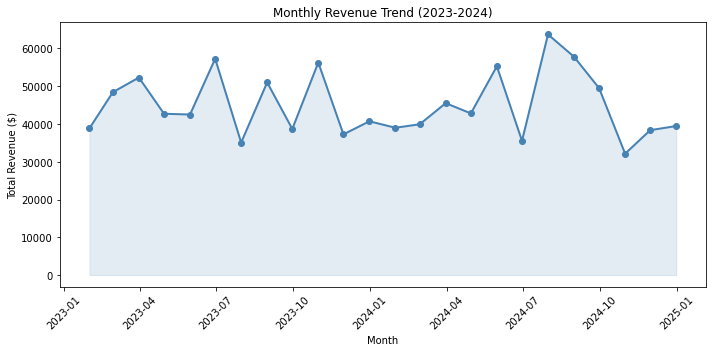

In [7]:
monthly = df.set_index('Order_Date').resample('M')['Revenue'].sum().reset_index()
monthly.columns = ['Month', 'Total_Revenue']

plt.figure(figsize=(10, 5))
plt.plot(monthly['Month'], monthly['Total_Revenue'], marker='o', linewidth=2, color='steelblue')
plt.fill_between(monthly['Month'], monthly['Total_Revenue'], alpha=0.15, color='steelblue')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.title('Monthly Revenue Trend (2023-2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Revenue fluctuates month-to-month without a clear long-term trend. Peaks likely correspond to months with more high-value orders.

### 2.3 Bar Chart - Average Revenue by Region

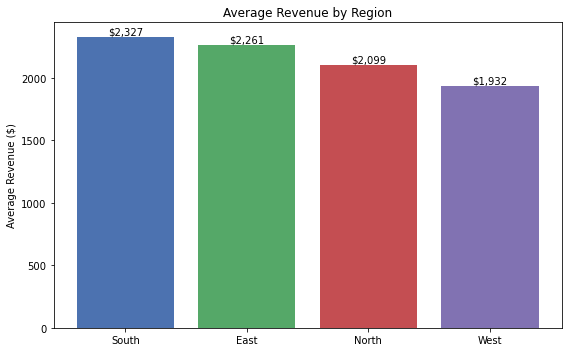

In [8]:
region_rev = df.groupby('Region')['Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(region_rev.index, region_rev.values, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.ylabel('Average Revenue ($)')
plt.title('Average Revenue by Region')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

**Insight:** The four regions have broadly comparable average revenues. Minor differences are attributable to random variation.

### 2.4 Histogram - Distribution of Customer Ratings

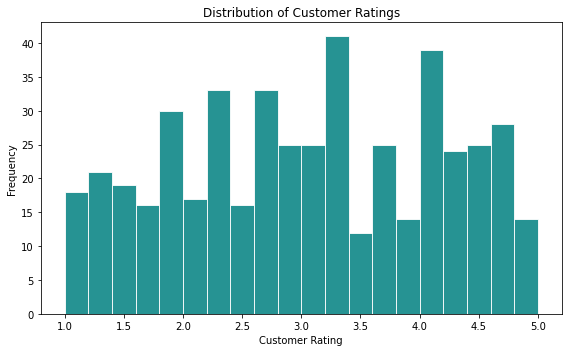

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df['Customer_Rating'].dropna(), bins=20, color='teal', edgecolor='white', alpha=0.85)
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Ratings')
plt.tight_layout()
plt.show()

**Insight:** Ratings are approximately uniformly distributed between 1 and 5, with no obvious skew.

### 2.5 Box Plot - Revenue Distribution by Category

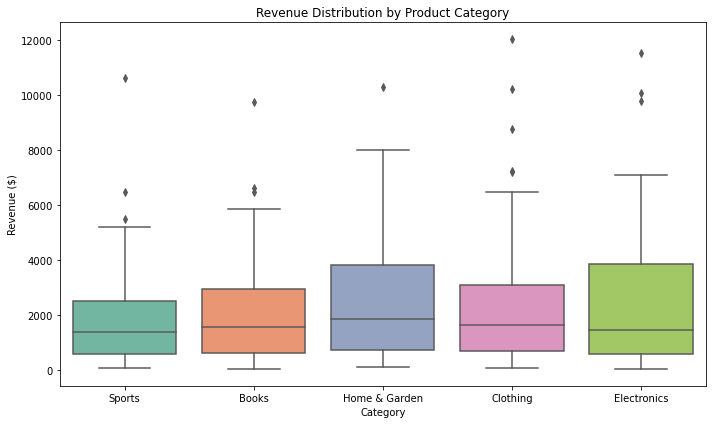

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Revenue', palette='Set2')
plt.title('Revenue Distribution by Product Category')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

**Insight:** All categories show right-skewed revenue distributions with several outliers on the upper end.

### 2.6 Pie Chart - Order Proportion by Customer Segment

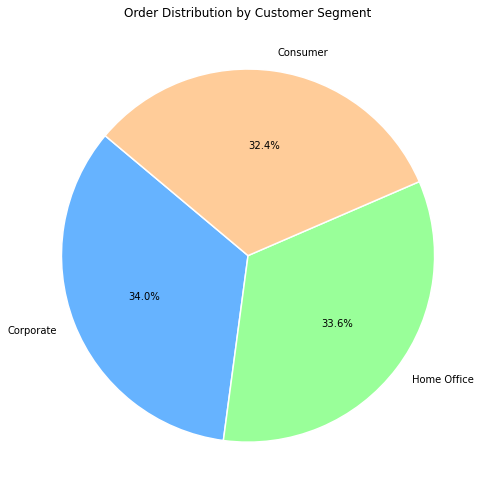

In [11]:
seg_counts = df['Customer_Segment'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        startangle=140, colors=['#66b3ff','#99ff99','#ffcc99'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Order Distribution by Customer Segment')
plt.tight_layout()
plt.show()

**Insight:** Orders are distributed roughly equally among Consumer, Corporate, and Home Office segments.

---
## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

In [12]:
print("Missing values BEFORE handling:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Missing values BEFORE handling:
Order_Date           0
Category             0
Region               0
Customer_Segment     0
Quantity             0
Unit_Price           0
Discount            25
Shipping_Cost       25
Customer_Rating     25
Revenue              0
Profit               0
dtype: int64

Total missing cells: 75


In [13]:
# Discount: fill with median
df['Discount'] = df['Discount'].fillna(df['Discount'].median())

# Customer_Rating: forward fill then backward fill
df.sort_values('Order_Date', inplace=True)
df['Customer_Rating'] = df['Customer_Rating'].ffill()
df['Customer_Rating'] = df['Customer_Rating'].bfill()

# Shipping_Cost: fill with mean
df['Shipping_Cost'] = df['Shipping_Cost'].fillna(df['Shipping_Cost'].mean())

# Recalculate derived columns
df['Revenue'] = np.round(df['Quantity'] * df['Unit_Price'] * (1 - df['Discount']), 2)
df['Profit']  = np.round(df['Revenue'] - df['Shipping_Cost'] - (df['Quantity'] * df['Unit_Price'] * 0.6), 2)

print("Missing values AFTER handling:")
print(df.isnull().sum())

Missing values AFTER handling:
Order_Date          0
Category            0
Region              0
Customer_Segment    0
Quantity            0
Unit_Price          0
Discount            0
Shipping_Cost       0
Customer_Rating     0
Revenue             0
Profit              0
dtype: int64


### 3.2 Outlier Detection and Removal (IQR Method)

In [14]:
Q1  = df['Revenue'].quantile(0.25)
Q3  = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f},  Q3 = {Q3:.2f},  IQR = {IQR:.2f}")
print(f"Lower bound = {lower_bound:.2f},  Upper bound = {upper_bound:.2f}")

outliers = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")
print("\nOutlier rows (Revenue):")
outliers[['Order_Date', 'Category', 'Quantity', 'Unit_Price', 'Revenue']].head(10)

Q1 = 607.85,  Q3 = 2961.88,  IQR = 2354.03
Lower bound = -2923.20,  Upper bound = 6492.92

Number of outliers detected: 12

Outlier rows (Revenue):


,Order_Date,Category,Quantity,Unit_Price,Revenue
36,2023-02-22 15:58:04.569138276,Home & Garden,19,486.68,6565.31
55,2023-03-22 11:03:43.647294589,Electronics,15,489.42,6974.24
84,2023-05-03 21:15:30.661322644,Electronics,18,451.18,6496.99
109,2023-06-09 11:00:50.501002004,Home & Garden,17,457.55,6922.73
151,2023-08-09 21:38:35.831663324,Electronics,17,459.29,7105.22
200,2023-10-20 14:02:38.717434868,Clothing,19,410.26,7249.29
240,2023-12-18 02:27:10.460921844,Home & Garden,17,490.71,8008.39
300,2024-03-14 21:03:58.076152304,Books,16,413.47,6615.52
399,2024-08-06 16:58:40.641282560,Clothing,18,494.20,7205.44
411,2024-08-24 06:18:02.164328656,Clothing,18,495.84,8746.62


In [15]:
print(f"Shape BEFORE outlier removal: {df.shape}")
df_clean = df[(df['Revenue'] >= lower_bound) & (df['Revenue'] <= upper_bound)].copy()
print(f"Shape AFTER  outlier removal: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Shape BEFORE outlier removal: (500, 11)
Shape AFTER  outlier removal: (488, 11)
Rows removed: 12


### 3.3 Data Reduction

In [16]:
print(f"Shape BEFORE reduction: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Shape BEFORE reduction: (488, 11)
Columns: ['Order_Date', 'Category', 'Region', 'Customer_Segment', 'Quantity', 'Unit_Price', 'Discount', 'Shipping_Cost', 'Customer_Rating', 'Revenue', 'Profit']


In [17]:
# Dimension elimination - drop less relevant columns
df_reduced = df_clean.drop(columns=['Shipping_Cost', 'Customer_Rating'])

# Sampling - take a 60% random sample
df_reduced = df_reduced.sample(frac=0.60, random_state=42)

print(f"Shape AFTER  reduction: {df_reduced.shape}")
print(f"Columns: {list(df_reduced.columns)}")
df_reduced.head()

Shape AFTER  reduction: (293, 9)
Columns: ['Order_Date', 'Category', 'Region', 'Customer_Segment', 'Quantity', 'Unit_Price', 'Discount', 'Revenue', 'Profit']


,Order_Date,Category,Region,Customer_Segment,Quantity,Unit_Price,Discount,Revenue,Profit
74,2023-04-19 06:09:22.725450902,Books,North,Consumer,3,433.89,0.23,1002.29,212.19
251,2024-01-03 04:39:55.190380760,Sports,North,Consumer,10,132.24,0.40,793.44,-49.97
448,2024-10-17 09:22:43.527054104,Electronics,West,Corporate,4,191.12,0.36,489.27,24.23
81,2023-04-29 11:55:40.280561122,Electronics,North,Corporate,17,383.77,0.37,4110.18,176.76
412,2024-08-25 17:24:38.957915832,Books,South,Corporate,12,485.52,0.11,5185.35,1641.87


### 3.4 Data Scaling and Discretization

In [18]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numeric_cols = ['Quantity', 'Unit_Price', 'Revenue', 'Profit']

print("BEFORE scaling (first 5 rows):")
print(df_reduced[numeric_cols].head().to_string())

BEFORE scaling (first 5 rows):
     Quantity  Unit_Price  Revenue   Profit
74          3      433.89  1002.29   212.19
251        10      132.24   793.44   -49.97
448         4      191.12   489.27    24.23
81         17      383.77  4110.18   176.76
412        12      485.52  5185.35  1641.87


In [19]:
# Min-Max Scaling
scaler_mm = MinMaxScaler()
df_minmax = df_reduced.copy()
df_minmax[numeric_cols] = scaler_mm.fit_transform(df_reduced[numeric_cols])

print("AFTER Min-Max Scaling (first 5 rows):")
print(df_minmax[numeric_cols].head().to_string())

AFTER Min-Max Scaling (first 5 rows):
     Quantity  Unit_Price   Revenue    Profit
74   0.111111    0.870046  0.149887  0.106031
251  0.500000    0.256287  0.117455  0.000000
448  0.166667    0.376089  0.070220  0.030010
81   0.888889    0.768068  0.632508  0.091701
412  0.611111    0.975096  0.799470  0.684268


In [20]:
# Z-score Standardization
scaler_z = StandardScaler()
df_zscore = df_reduced.copy()
df_zscore[numeric_cols] = scaler_z.fit_transform(df_reduced[numeric_cols])

print("AFTER Z-score Standardization (first 5 rows):")
print(df_zscore[numeric_cols].head().to_string())

AFTER Z-score Standardization (first 5 rows):
     Quantity  Unit_Price   Revenue    Profit
74  -1.362240    1.444997 -0.571492 -0.434793
251 -0.031786   -0.779548 -0.708721 -0.996336
448 -1.172175   -0.345332 -0.908584 -0.837400
81   1.298668    1.075383  1.470622 -0.510684
412  0.348344    1.825748  2.177088  2.627560


In [21]:
# Discretization - bin Revenue into categories
df_disc = df_reduced.copy()
df_disc['Revenue_Tier'] = pd.cut(df_disc['Revenue'], bins=3, labels=['Low', 'Medium', 'High'])

print("Revenue discretized into tiers:")
print(df_disc[['Revenue', 'Revenue_Tier']].head(10).to_string())
print(f"\nTier value counts:\n{df_disc['Revenue_Tier'].value_counts()}")

Revenue discretized into tiers:
     Revenue Revenue_Tier
74   1002.29          Low
251   793.44          Low
448   489.27          Low
81   4110.18       Medium
412  5185.35         High
491  1406.27          Low
205  1557.21          Low
65   4026.64       Medium
87   4638.27         High
315   118.89          Low

Tier value counts:
Low       196
Medium     68
High       29
Name: Revenue_Tier, dtype: int64


---
## Step 4: Statistical Analysis

We use the cleaned (unscaled) dataset df_clean for meaningful statistics.

### 4.1 General Overview

In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 488 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_Date        488 non-null    datetime64[ns]
 1   Category          488 non-null    object        
 2   Region            488 non-null    object        
 3   Customer_Segment  488 non-null    object        
 4   Quantity          488 non-null    int64         
 5   Unit_Price        488 non-null    float64       
 6   Discount          488 non-null    float64       
 7   Shipping_Cost     488 non-null    float64       
 8   Customer_Rating   488 non-null    float64       
 9   Revenue           488 non-null    float64       
 10  Profit            488 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(3)
memory usage: 45.8+ KB


In [23]:
df_clean.describe()

,Quantity,Unit_Price,Discount,Shipping_Cost,Customer_Rating,Revenue,Profit
count,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000
mean,9.954918,241.846168,0.203463,27.184248,3.023566,1888.509098,422.452131
std,5.324194,136.882211,0.112845,13.715987,1.113441,1582.432657,482.659694
min,1.000000,5.160000,0.000000,2.020000,1.000000,36.620000,-49.970000
25%,5.000000,120.872500,0.110000,15.805000,2.100000,599.065000,62.517500
50%,10.000000,242.240000,0.200000,27.171105,3.000000,1413.130000,250.340000
75%,14.000000,344.827500,0.300000,39.185000,4.000000,2830.452500,640.960000
max,19.000000,497.760000,0.400000,49.990000,5.000000,6491.750000,2422.510000


### 4.2 Central Tendency Measures

In [24]:
numeric = df_clean.select_dtypes(include='number')

central = pd.DataFrame({
    'Min':    numeric.min(),
    'Max':    numeric.max(),
    'Mean':   numeric.mean(),
    'Median': numeric.median(),
    'Mode':   numeric.mode().iloc[0]
})
central.round(2)

,Min,Max,Mean,Median,Mode
Quantity,1.00,19.00,9.95,10.00,12.00
Unit_Price,5.16,497.76,241.85,242.24,5.16
Discount,0.00,0.40,0.20,0.20,0.20
Shipping_Cost,2.02,49.99,27.18,27.17,27.08
Customer_Rating,1.00,5.00,3.02,3.00,2.70
Revenue,36.62,6491.75,1888.51,1413.13,36.62
Profit,-49.97,2422.51,422.45,250.34,-49.97


### 4.3 Dispersion Measures

In [25]:
dispersion = pd.DataFrame({
    'Range':     numeric.max() - numeric.min(),
    'Q1':        numeric.quantile(0.25),
    'Q3':        numeric.quantile(0.75),
    'IQR':       numeric.quantile(0.75) - numeric.quantile(0.25),
    'Variance':  numeric.var(),
    'Std_Dev':   numeric.std()
})
dispersion.round(2)

,Range,Q1,Q3,IQR,Variance,Std_Dev
Quantity,18.00,5.00,14.00,9.00,28.35,5.32
Unit_Price,492.60,120.87,344.83,223.96,18736.74,136.88
Discount,0.40,0.11,0.30,0.19,0.01,0.11
Shipping_Cost,47.97,15.80,39.18,23.38,188.13,13.72
Customer_Rating,4.00,2.10,4.00,1.90,1.24,1.11
Revenue,6455.13,599.06,2830.45,2231.39,2504093.11,1582.43
Profit,2472.48,62.52,640.96,578.44,232960.38,482.66


### 4.4 Correlation Analysis

In [26]:
corr_matrix = numeric.corr().round(3)
print("Correlation Matrix:")
corr_matrix

Correlation Matrix:


,Quantity,Unit_Price,Discount,Shipping_Cost,Customer_Rating,Revenue,Profit
Quantity,1.000,-0.013,0.112,-0.004,-0.028,0.626,0.454
Unit_Price,-0.013,1.000,0.046,0.023,-0.004,0.656,0.480
Discount,0.112,0.046,1.000,-0.016,-0.052,-0.070,-0.469
Shipping_Cost,-0.004,0.023,-0.016,1.000,-0.035,0.010,-0.011
Customer_Rating,-0.028,-0.004,-0.052,-0.035,1.000,-0.018,-0.016
Revenue,0.626,0.656,-0.070,0.010,-0.018,1.000,0.842
Profit,0.454,0.480,-0.469,-0.011,-0.016,0.842,1.000


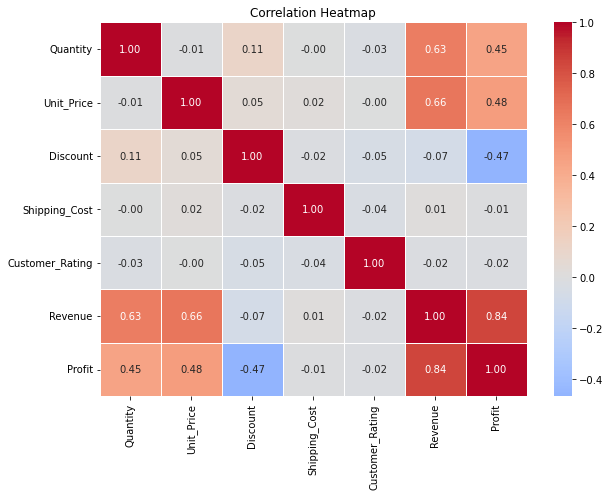

In [27]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Key correlation insights:**
- Revenue and Quantity show a moderate positive correlation.
- Revenue and Unit_Price are also positively correlated.
- Profit is strongly correlated with Revenue, which is expected since profit is derived from revenue.
- Discount shows a slight negative correlation with Revenue.

---
## Summary

| Step | Key Takeaway |
|------|-------------|
| Data Collection | 500-row synthetic retail sales dataset with 11 features |
| Visualization | Six chart types revealed revenue distributions, category patterns, and temporal trends |
| Preprocessing | Imputed ~5% missing values, removed IQR-based outliers, reduced dimensions and sampled 60% |
| Statistical Analysis | Computed central tendency, dispersion, and correlations; Revenue-Quantity and Revenue-Profit show strongest relationships |